# Gradient Boosting — The Library Version

Same model via scikit-learn, verifying the scratch build — with `staged_predict` (our assembly-line replay, built in) and early stopping as a constructor flag. Plus the family tree: what XGBoost/LightGBM add (README §8 Q6).

test RMSE: 28.8   R²: 0.94   <- same ballpark as the scratch build


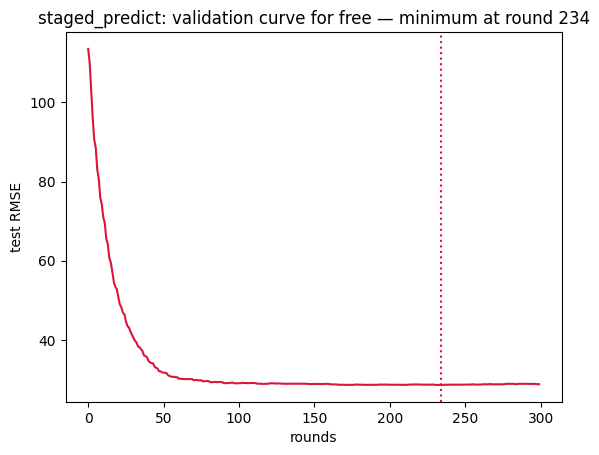

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score

df = pd.read_csv("data/bike_data.csv")
X = df[["hour"]].values
y = df["rentals"].values.astype(float)
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, random_state=66)

model = GradientBoostingRegressor(n_estimators=300, learning_rate=0.1, max_depth=2,   # our exact knobs
                                  random_state=0)
model.fit(Xtr, ytr)
pred = model.predict(Xte)
print(f"test RMSE: {np.sqrt(mean_squared_error(yte, pred)):.1f}   R²: {r2_score(yte, pred):.2f}   <- same ballpark as the scratch build")

# staged_predict = our Block 7 replay, for free
te_curve = [np.sqrt(mean_squared_error(yte, p)) for p in model.staged_predict(Xte)]
plt.plot(te_curve, color="crimson")
plt.axvline(int(np.argmin(te_curve)), ls=":", color="crimson")
plt.xlabel("rounds"); plt.ylabel("test RMSE")
plt.title(f"staged_predict: validation curve for free — minimum at round {int(np.argmin(te_curve))}")
plt.show()

In [2]:
# Early stopping as a flag: hold out 15% internally, stop when it stalls for 20 rounds.
es = GradientBoostingRegressor(n_estimators=2000, learning_rate=0.05, max_depth=2,
                               validation_fraction=0.15, n_iter_no_change=20, random_state=0)
es.fit(Xtr, ytr)
print(f"asked for up to 2000 rounds; early stopping kept {es.n_estimators_}")
print(f"test RMSE: {np.sqrt(mean_squared_error(yte, es.predict(Xte))):.1f}")
print()
print("The industrial lineage (README §8 Q6): XGBoost / LightGBM / CatBoost = this same")
print("assembly line + curvature-aware steps, L1/L2 leaf penalties, histogram split-finding,")
print("native missing values, and heavy parallelism. Different engine room, same philosophy.")

asked for up to 2000 rounds; early stopping kept 115
test RMSE: 30.9

The industrial lineage (README §8 Q6): XGBoost / LightGBM / CatBoost = this same
assembly line + curvature-aware steps, L1/L2 leaf penalties, histogram split-finding,
native missing values, and heavy parallelism. Different engine room, same philosophy.


**The takeaway:** `GradientBoostingRegressor.fit()` is Blocks 4–6 of the scratch notebook; `learning_rate`, `n_estimators`, `max_depth` are the exact knobs you hand-tuned; `staged_predict` is your replay; early stopping is §3.4 as a flag. The tabular champion, and you've built its heart.